Качанов Даниил Владимирович P3306

Лабораторная 3. Линейная регрессия

- Выбор датасетов:
    - Студенты с **четным** порядковым номером в группе должны использовать набор данных о [жилье в Калифорнии](https://developers.google.com/machine-learning/crash-course/california-housing-data-description?hl=ru) Скачать [тут](https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv)
    - Студенты с **нечетным** порядковым номером в группе должны использовать [про обучение студентов](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)


Я на **восьмом** месте в группе, поэтому использую первый набор данных.

In [9]:
import pandas as pd
import numpy as np 
import random as rnd
from typing import *
from linear_model import *
import metrics
import matplotlib.pyplot as plt


In [10]:
url = "https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv"

df = pd.read_csv(url)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


Получите и визуализируйте (графически) статистику по датасету (включая количество, среднее значение, стандартное отклонение, минимум, максимум и различные квантили).

Количество

In [3]:
len(df)

17000

Средние значения

In [4]:
df.mean()

longitude               -119.562108
latitude                  35.625225
housing_median_age        28.589353
total_rooms             2643.664412
total_bedrooms           539.410824
population              1429.573941
households               501.221941
median_income              3.883578
median_house_value    207300.912353
dtype: float64

Стандартное отклонение

In [5]:
df.std()

longitude                  2.005166
latitude                   2.137340
housing_median_age        12.586937
total_rooms             2179.947071
total_bedrooms           421.499452
population              1147.852959
households               384.520841
median_income              1.908157
median_house_value    115983.764387
dtype: float64

Минимум и максимум

In [6]:
(df.min(), df.max())

(longitude              -124.3500
 latitude                 32.5400
 housing_median_age        1.0000
 total_rooms               2.0000
 total_bedrooms            1.0000
 population                3.0000
 households                1.0000
 median_income             0.4999
 median_house_value    14999.0000
 dtype: float64,
 longitude               -114.3100
 latitude                  41.9500
 housing_median_age        52.0000
 total_rooms            37937.0000
 total_bedrooms          6445.0000
 population             35682.0000
 households              6082.0000
 median_income             15.0001
 median_house_value    500001.0000
 dtype: float64)

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Визуализируем

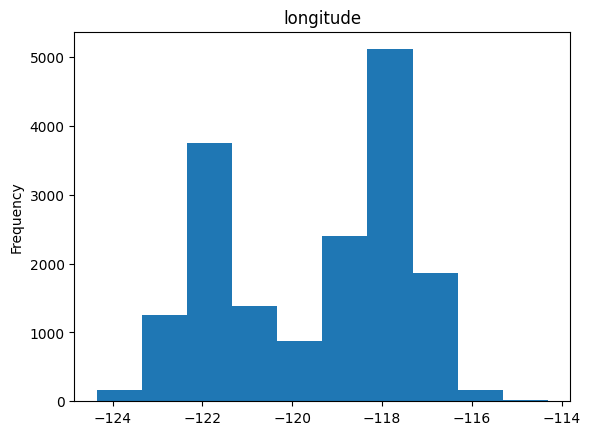

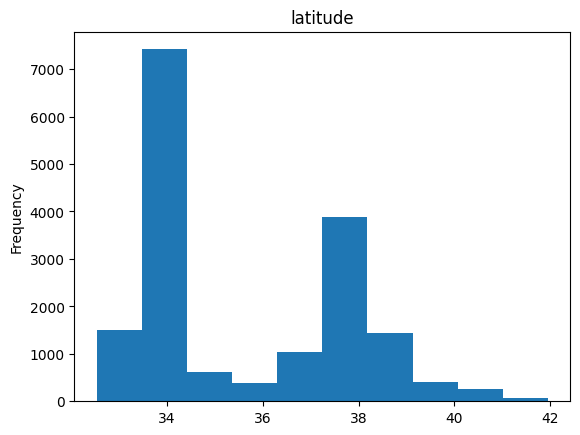

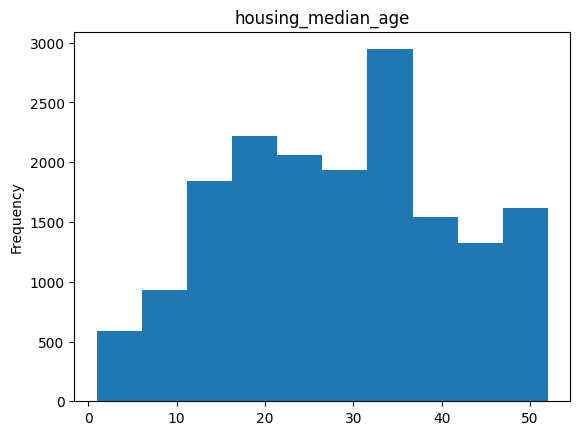

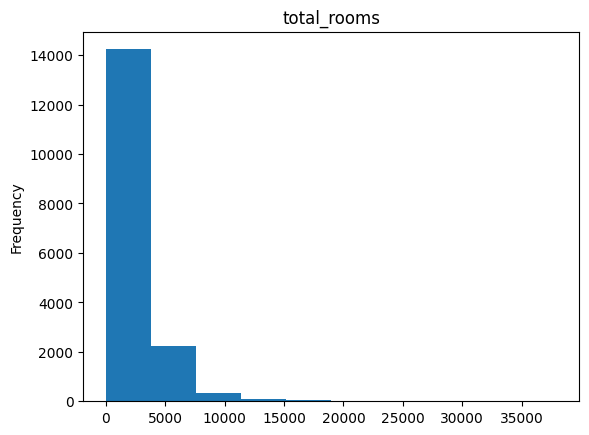

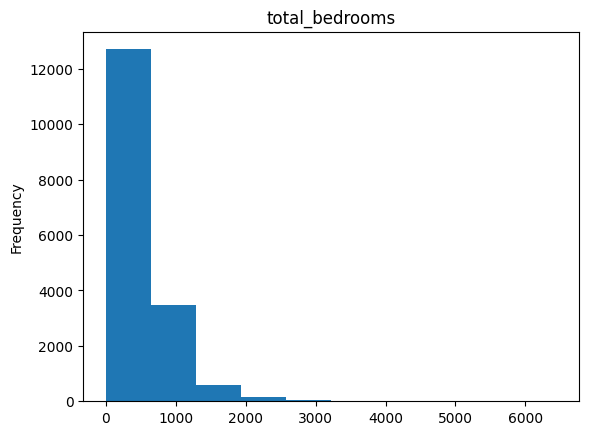

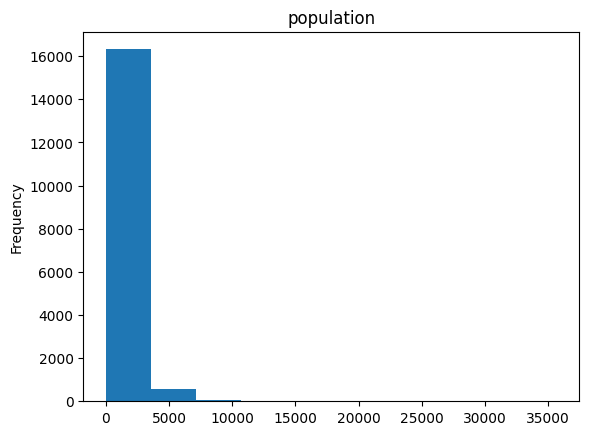

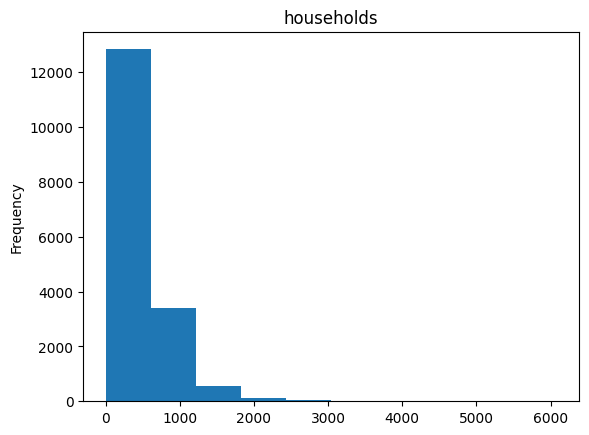

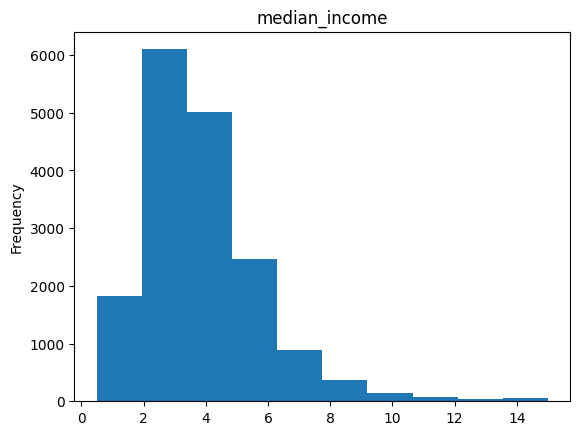

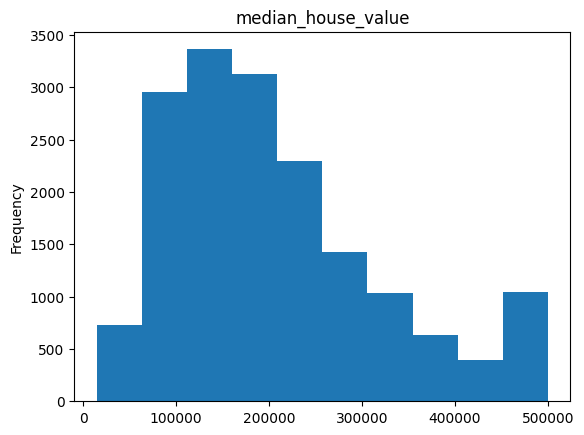

In [11]:
for f in df.columns:
    df[f].plot(kind="hist")
    plt.title(f)
    plt.show()


Проведи предварительную обработку данных, включая обработку отсутствующих значений, кодирование категориальных признаков и нормировку

In [12]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

Отсутствующие значения отсутствуют.
Вот как можно было бы работать с ними:

In [13]:
df = df.fillna(df.mean())

Или просто избавиться от строк с пропусками

In [14]:
df = df.dropna()

Проведем Min-Max нормализацию.

In [15]:
df = (df - df.min())/(df.max() - df.min())
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,1.000000,0.175345,0.274510,0.147885,0.198945,0.028364,0.077454,0.068530,0.107012
1,0.984064,0.197662,0.352941,0.201608,0.294848,0.031559,0.075974,0.091040,0.134228
2,0.975100,0.122210,0.313725,0.018927,0.026847,0.009249,0.019076,0.079378,0.145775
3,0.974104,0.116897,0.254902,0.039515,0.052142,0.014350,0.037000,0.185639,0.120414
4,0.974104,0.109458,0.372549,0.038276,0.050435,0.017405,0.042921,0.098281,0.104125
...,...,...,...,...,...,...,...,...,...
16995,0.008964,0.854410,1.000000,0.058389,0.060987,0.025337,0.060516,0.128081,0.198764
16996,0.007968,0.866100,0.686275,0.061869,0.081782,0.033381,0.076303,0.139170,0.131960
16997,0.004980,0.988310,0.313725,0.070515,0.082247,0.034782,0.074823,0.174577,0.182682
16998,0.004980,0.984060,0.352941,0.070384,0.085506,0.036296,0.078441,0.102054,0.145981


In [16]:
df.sample(20)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
2295,0.688247,0.163656,0.274510,0.132384,0.153786,0.089829,0.161158,0.213969,0.209073
12187,0.287849,0.649309,0.254902,0.083432,0.085351,0.050001,0.087486,0.228452,0.160001
1779,0.706175,0.200850,0.196078,0.121128,0.121198,0.070938,0.127446,0.195646,0.173816
16608,0.163347,0.625930,1.000000,0.037881,0.050279,0.020600,0.051801,0.119054,0.236908
13576,0.237052,0.504782,0.549020,0.071675,0.105680,0.044816,0.106068,0.195659,0.516082
7539,0.596614,0.146652,0.490196,0.097351,0.177374,0.064604,0.165762,0.149432,0.441856
12818,0.252988,0.506908,0.274510,0.047239,0.056642,0.042882,0.060845,0.364436,0.401856
1005,0.722112,0.048884,0.078431,0.408594,0.405338,0.207797,0.387601,0.373064,0.507423
12115,0.289841,0.648247,0.470588,0.044181,0.056797,0.027131,0.050321,0.037234,0.097115
2963,0.654382,0.168969,0.333333,0.205509,0.180012,0.103899,0.201612,0.371167,0.506186


In [17]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,1.000000,0.175345,0.274510,0.147885,0.198945,0.028364,0.077454,0.068530,0.107012
1,0.984064,0.197662,0.352941,0.201608,0.294848,0.031559,0.075974,0.091040,0.134228
2,0.975100,0.122210,0.313725,0.018927,0.026847,0.009249,0.019076,0.079378,0.145775
3,0.974104,0.116897,0.254902,0.039515,0.052142,0.014350,0.037000,0.185639,0.120414
4,0.974104,0.109458,0.372549,0.038276,0.050435,0.017405,0.042921,0.098281,0.104125


Как мы можем заметить, категориальные признаки в выборке отсутствуют

Разделите данные на обучающий и тестовый наборы данных.

Перемешаем выборку и разделим ее

In [ ]:

rnd_split = rnd.randrange(int(3/7 * len(df)), int(5/7 * len(df)))
rnd_split
X_train, y_train = df[:rnd_split].transpose()[:-1].transpose(), df[:rnd_split]["median_house_value"] 
X_test, y_test = df[rnd_split:].transpose()[:-1].transpose(), df[rnd_split:]["median_house_value"] 
X_train["ones"] = np.ones(len(X_train))
X_train
X_test["ones"] = np.ones(len(X_test))
X_test

In [ ]:
df.clip()

Инициализируем вектор весов

In [17]:
num_features = len(X_train.T)  # Количество признаков
W = [rnd.random() for _ in range(num_features)]

Предсказание нашей модели

In [ ]:
def predict(w: list[int], x) -> float:
    return np.dot(w, x);

predict(W, X_train.iloc[0])

Функция ошибки

In [ ]:
def MSE(W, x, y):
    return np.mean([(predict(W, x.iloc[i]) - y.iloc[i])**2 for i in range(len(y))])

MSE(W, X_train, y_train)

In [ ]:
lr = 0.00001
for i in range(50):
    f = X_train.dot(W)
    err = f - y_train
    grad = 2 * X_train.T.dot(err)
    W -= lr * grad
    print(MSE(W, X_train, y_train))

In [ ]:
MSE(W, X_test, y_test)

In [ ]:
W